# Import Library

In [1]:
# Import library 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder 
from sklearn.preprocessing import LabelEncoder   
from sklearn.preprocessing import OneHotEncoder 

from scipy import stats
from scipy.special import factorial

from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict
from statsmodels.tools.eval_measures import mse, rmse
from sklearn import preprocessing

import warnings

## Style from matplotlib

In [2]:
# list of available styles in matplotlib
print(plt.style.available)

# uss of style from matplotlib
plt.style.use('ggplot')

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


## Set option in pandas to display all rows and columns in dataset

In [3]:
# set pandas display options for rows and columns
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows", None)

## Ignore library Deprecated warning messages

In [4]:
# define function
def ignore_warning():  
    return warnings.filterwarnings(action='ignore')

# function call
ignore_warning() 


## Load Dataset

In [126]:
 # define function
def load_dataset(dataset_url):
     # to read csv data
    return pd.read_csv(dataset_url)
 
# call function load_dataset() and store dataset value in population_dataframe
population_dataframe = load_dataset(r'./estimated_population.csv')
population_dataframe.head()

,STATISTIC Label,Year,Age Group,Sex,Region,UNIT,VALUE
0,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,State,Thousand,356.0
1,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Border,Thousand,30.7
2,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,West,Thousand,32.6
3,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Mid-West,Thousand,35.0
4,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,South-East,Thousand,32.0


# EDA (Exploratory Data Analysis)

#### Shape of Dataset

In [6]:
# Dimensions of dataset
population_dataframe.shape

(6669, 7)

#### First 10 observation

In [7]:
# Gives top 10 rows of dataset
population_dataframe.head(10)

,STATISTIC Label,Year,Age Group,Sex,Region,UNIT,VALUE
0,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,State,Thousand,356.0
1,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Border,Thousand,30.7
2,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,West,Thousand,32.6
3,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Mid-West,Thousand,35.0
4,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,South-East,Thousand,32.0
5,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,South-West,Thousand,50.1
6,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Dublin,Thousand,93.3
7,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Mid-East,Thousand,58.5
8,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Midland,Thousand,23.9
9,Estimated Population (Persons in April),2011,0 - 4 years,Male,State,Thousand,182.0


#### Last 5 observation

In [8]:
# Gives bottom 5 rows of dataset
population_dataframe.tail()

,STATISTIC Label,Year,Age Group,Sex,Region,UNIT,VALUE
6664,Estimated Population (Persons in April),2023,All ages,Female,South-East,Thousand,237.5
6665,Estimated Population (Persons in April),2023,All ages,Female,South-West,Thousand,383.8
6666,Estimated Population (Persons in April),2023,All ages,Female,Dublin,Thousand,765.6
6667,Estimated Population (Persons in April),2023,All ages,Female,Mid-East,Thousand,391.3
6668,Estimated Population (Persons in April),2023,All ages,Female,Midland,Thousand,163.2


#### Random 10 observation

In [9]:
# Gives random sample data
population_dataframe.sample(10)

,STATISTIC Label,Year,Age Group,Sex,Region,UNIT,VALUE
3332,Estimated Population (Persons in April),2017,45 - 49 years,Male,West,Thousand,15.7
5838,Estimated Population (Persons in April),2022,35 - 39 years,Both sexes,Dublin,Thousand,120.8
178,Estimated Population (Persons in April),2011,30 - 34 years,Male,Mid-East,Thousand,27.6
3635,Estimated Population (Persons in April),2018,5 - 9 years,Male,Midland,Thousand,12.0
1594,Estimated Population (Persons in April),2014,10 - 14 years,Both sexes,Border,Thousand,28.1
483,Estimated Population (Persons in April),2011,85 years and over,Female,Dublin,Thousand,10.3
4131,Estimated Population (Persons in April),2019,5 - 9 years,Both sexes,State,Thousand,355.9
519,Estimated Population (Persons in April),2012,0 - 4 years,Both sexes,Dublin,Thousand,94.0
3625,Estimated Population (Persons in April),2018,5 - 9 years,Both sexes,Mid-East,Thousand,59.9
1498,Estimated Population (Persons in April),2013,85 years and over,Male,South-East,Thousand,1.8


#### Function to create dictionary of existing and new columns name i.e {old: new}

In [10]:
# rename columns name i.e no space should be in columns name
# use of try and except to handle if value list has not appropriate length for column
new_column_name = ['statistic_label','year','age_group','sex','region','unit','value']

def columns_dict(cols):
    new_col = {}
    
    if len(cols) == len(population_dataframe.columns):
        try:
            for i in range(len(cols)):
                new_col[population_dataframe.columns[i]] = cols[i]
        except:
            print("An error occurred while creating the column dictionary.")
    else:
        print(f"Your length of Population Dataframe {len(population_dataframe.columns)} != {len(new_column_name)} with length of New Column ")
    
    return new_col

col_dict = columns_dict(new_column_name)


#### Rename Column names

In [11]:
# inplace = True set the values permenantly so that we can use new columns name
population_dataframe.rename(columns=col_dict, inplace=True)
population_dataframe.head()

,statistic_label,year,age_group,sex,region,unit,value
0,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,State,Thousand,356.0
1,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Border,Thousand,30.7
2,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,West,Thousand,32.6
3,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Mid-West,Thousand,35.0
4,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,South-East,Thousand,32.0


#### Drop column

In [12]:
# drop column STATISTIC Label and Unit because it
population_dataframe.drop({'statistic_label', 'unit'}, axis=1, inplace=True)
population_dataframe.head()

,year,age_group,sex,region,value
0,2011,0 - 4 years,Both sexes,State,356.0
1,2011,0 - 4 years,Both sexes,Border,30.7
2,2011,0 - 4 years,Both sexes,West,32.6
3,2011,0 - 4 years,Both sexes,Mid-West,35.0
4,2011,0 - 4 years,Both sexes,South-East,32.0


#### Check data types of columnns

In [13]:
# Checking the types of data
population_dataframe.dtypes

year           int64
age_group     object
sex           object
region        object
value        float64
dtype: object

#### Check is there null value on dataset

In [14]:
# isna().sum() provide sum of null value in each column in datasets
population_dataframe.isnull().sum()

year         0
age_group    0
sex          0
region       0
value        0
dtype: int64

#### Gives information about dataset

In [15]:
# info() provide information about datasets
population_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6669 entries, 0 to 6668
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       6669 non-null   int64  
 1   age_group  6669 non-null   object 
 2   sex        6669 non-null   object 
 3   region     6669 non-null   object 
 4   value      6669 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 260.6+ KB


#### Count total observation in each column

In [16]:
# count total items in each column
population_dataframe.count()

year         6669
age_group    6669
sex          6669
region       6669
value        6669
dtype: int64

#### Check Duplicated value

In [17]:
# count duplicated value in dataset
population_dataframe.duplicated().sum()

0

#### Describe the stastical value of dataset

In [18]:
# describe() generate statistical descriptive value of dataset
population_dataframe.describe()

,year,value
count,6669.000000,6669.000000
mean,2017.000000,75.670460
std,3.741938,281.512172
min,2011.000000,1.200000
25%,2014.000000,12.500000
50%,2017.000000,20.700000
75%,2020.000000,42.200000
max,2023.000000,5281.600000


#### Description about object type column in dataset

In [19]:
# describe(include=object) generate statistical descriptive value for object datatype of dataset
population_dataframe.describe(include=object)

,age_group,sex,region
count,6669,6669,6669
unique,19,3,9
top,0 - 4 years,Both sexes,State
freq,351,2223,741


#### Display Unique value in each column

In [20]:
# It return all unique value of series object
population_dataframe['age_group'].unique()

array(['0 - 4 years', '5 - 9 years', '10 - 14 years', '15 - 19 years',
       '20 - 24 years', '25 - 29 years', '30 - 34 years', '35 - 39 years',
       '40 - 44 years', '45 - 49 years', '50 - 54 years', '55 - 59 years',
       '60 - 64 years', '65 - 69 years', '70 - 74 years', '75 - 79 years',
       '80 - 84 years', '85 years and over', 'All ages'], dtype=object)

In [21]:
# It return all unique value of series object
population_dataframe['year'].unique()

array([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023])

### Before data cleaning 

#### Boxplot to check outliers in dataset

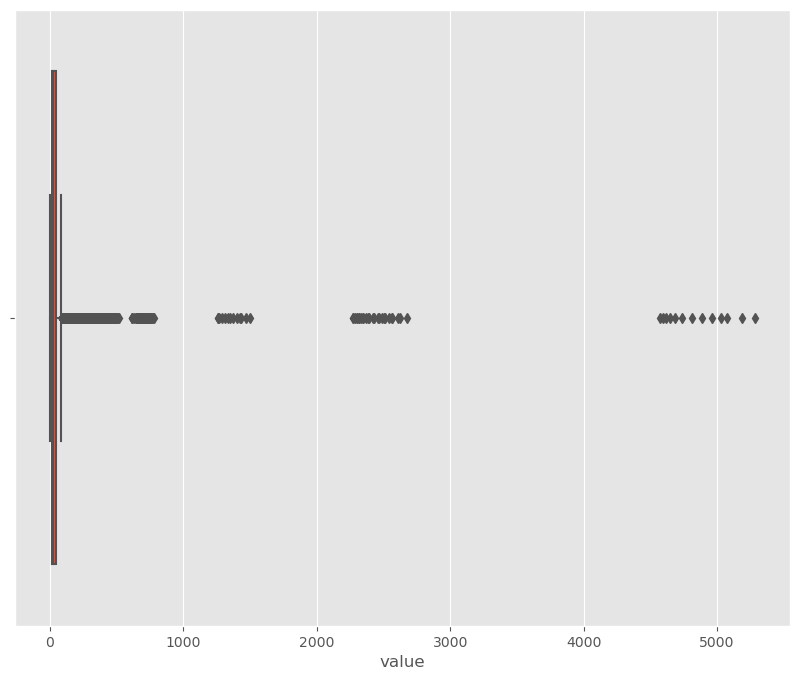

In [22]:
# This shows alot of outlilers
plt.figure(figsize=(10,8))
sns.boxplot( data = population_dataframe, x='value');

#### Histplot to see distribution of data

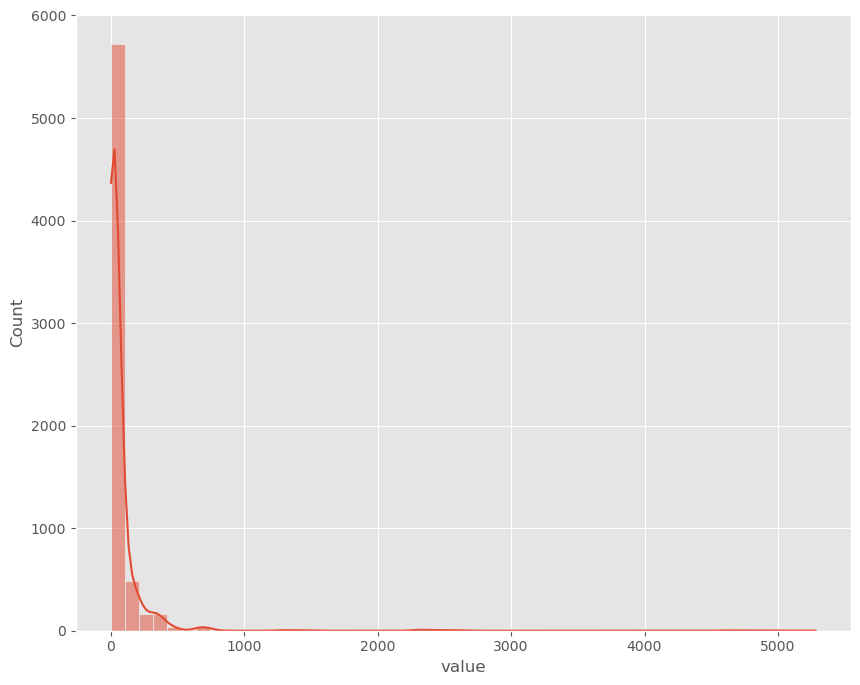

In [23]:
# Histplot explain distribution of data i.e Right skewed distribution  data
plt.figure(figsize=(10,8))
sns.histplot(data=population_dataframe, x='value', kde=True, bins=50);

#### Skew value

In [24]:
# best skew value should be -3 to +3
pop_skew_value = stats.skew(population_dataframe['value'], axis=0, bias=True)
print('Skew Value',pop_skew_value)

Skew Value 12.189813542687517


#### Kurtosis value

In [25]:
# best kurtosis value should be -10 to +10
kurtosis_value = stats.kurtosis(population_dataframe['value'], axis=0, bias=True)
print('kurtosis Value',kurtosis_value)

kurtosis Value 181.20115052099445


#### Pairplot to see data from different perspectives

<Figure size 1000x800 with 0 Axes>

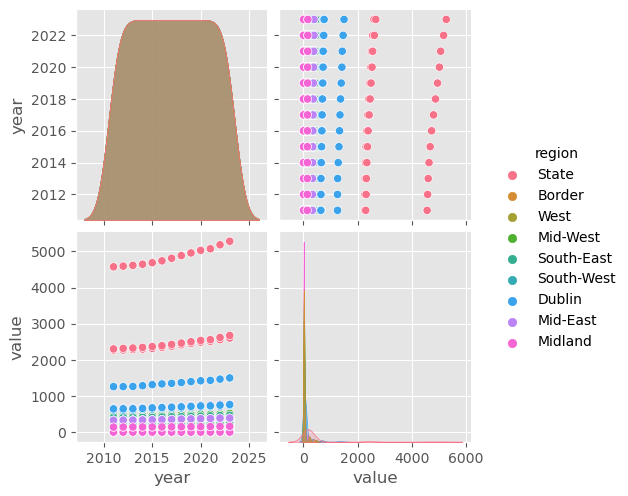

In [26]:
# plot pairplot
plt.figure(figsize=(10,8))
sns.pairplot(population_dataframe, hue="region");

#### Remove State from observation

In [27]:
# Remove State observation from region because state is sum of all other 8 region population
new_population_dataframe = population_dataframe.loc[population_dataframe['region'] != 'State']
new_population_dataframe.head()

,year,age_group,sex,region,value
1,2011,0 - 4 years,Both sexes,Border,30.7
2,2011,0 - 4 years,Both sexes,West,32.6
3,2011,0 - 4 years,Both sexes,Mid-West,35.0
4,2011,0 - 4 years,Both sexes,South-East,32.0
5,2011,0 - 4 years,Both sexes,South-West,50.1


#### Unique value of region column

In [28]:
# Unique region 
new_population_dataframe['region'].unique()

array(['Border', 'West', 'Mid-West', 'South-East', 'South-West', 'Dublin',
       'Mid-East', 'Midland'], dtype=object)

#### Unique value of sex column

In [29]:
# Unique sex 
new_population_dataframe['sex'].unique()

array(['Both sexes', 'Male', 'Female'], dtype=object)

#### Unique value of age_group column

In [30]:
# Unique age_group
new_population_dataframe['age_group'].unique()

array(['0 - 4 years', '5 - 9 years', '10 - 14 years', '15 - 19 years',
       '20 - 24 years', '25 - 29 years', '30 - 34 years', '35 - 39 years',
       '40 - 44 years', '45 - 49 years', '50 - 54 years', '55 - 59 years',
       '60 - 64 years', '65 - 69 years', '70 - 74 years', '75 - 79 years',
       '80 - 84 years', '85 years and over', 'All ages'], dtype=object)

#### Remove Both sexes and All age group from observation

In [31]:
# Remove Both sexes observation from sex column and All ages observation from age_group column because both sexes is sum of male and female population and all ages are sum of rest of categorical age
new_population_dataframe = new_population_dataframe.loc[(new_population_dataframe['sex'] != 'Both sexes') & (new_population_dataframe['age_group'] != 'All ages')]
new_population_dataframe.reset_index(drop=True, inplace=True)
new_population_dataframe.tail(5)

,year,age_group,sex,region,value
3739,2023,85 years and over,Female,South-East,5.0
3740,2023,85 years and over,Female,South-West,8.1
3741,2023,85 years and over,Female,Dublin,15.5
3742,2023,85 years and over,Female,Mid-East,6.0
3743,2023,85 years and over,Female,Midland,3.0


#### Function to plot boxplot

In [32]:
# Boxplot helps to identify outliers
def plot_boxplot(data_frame, col_name):
    plt.figure(figsize=(10,8))
    sns.boxplot(data = data_frame, x=col_name);

#### Boxplot for year column

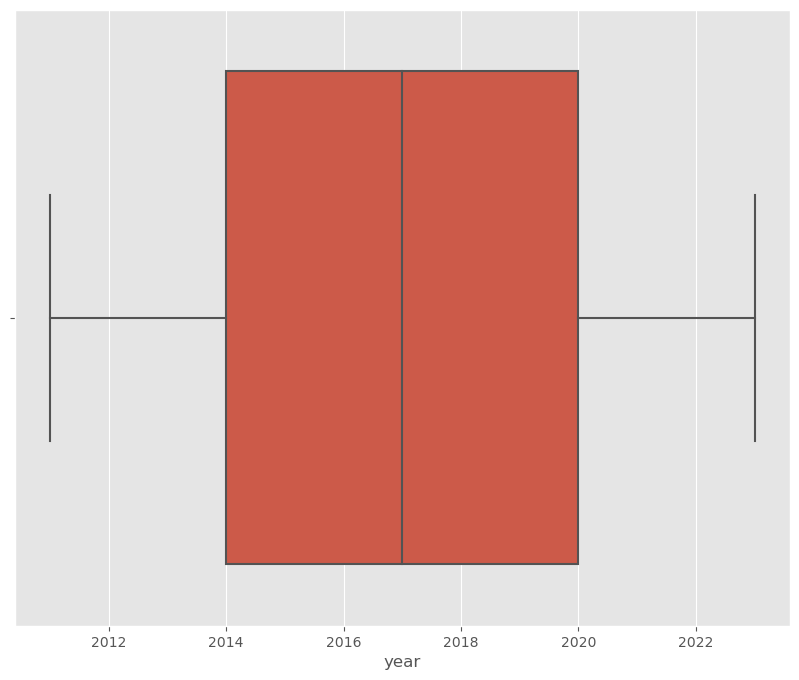

In [33]:
# call plot_boxplot for year column, Hence there are no outliers
plot_boxplot(new_population_dataframe, 'year')

#### Boxplot for value column

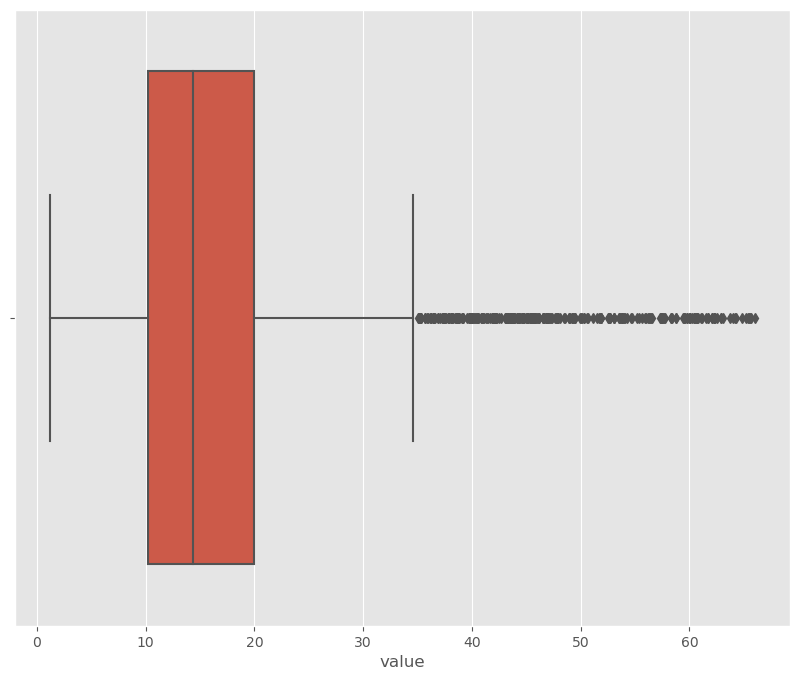

In [34]:
# call plot_boxplot function for value column, Hence there are outliers
plot_boxplot(new_population_dataframe, 'value')

#### Function to remove outliers

In [35]:
# Function to remove outliers from datasets by using IQR (Interquartile Range)

def remove_outliers(dataframe, col_name):
    Q1 = dataframe[col_name].quantile(0.25)
    Q3 = dataframe[col_name].quantile(0.75)
    IQR = Q3-Q1 
    lower_limit = Q1 - 1.5*IQR
    upper_limit = Q3 + 1.5*IQR
    print('IQR',IQR)
    print('lower_limit',lower_limit)
    print('upper_limit',upper_limit)
    new_data = dataframe[(dataframe['value'] > lower_limit) & (dataframe['value'] < upper_limit)]
    return new_data
 
# 1st degree to remove outliers    
newdata_no_outliers = remove_outliers(new_population_dataframe, 'value')

IQR 9.8
lower_limit -4.500000000000002
upper_limit 34.7


In [36]:
# 2st degree to remove outliers
newdata_no_outliers = remove_outliers(newdata_no_outliers, 'value')

IQR 7.600000000000001
lower_limit -1.7000000000000028
upper_limit 28.700000000000003


In [37]:
# 3st degree to remove outliers
newdata_no_outliers = remove_outliers(newdata_no_outliers, 'value')

IQR 7.200000000000001
lower_limit -1.200000000000001
upper_limit 27.6


### After data cleaning

#### Boxplot after removing outliers

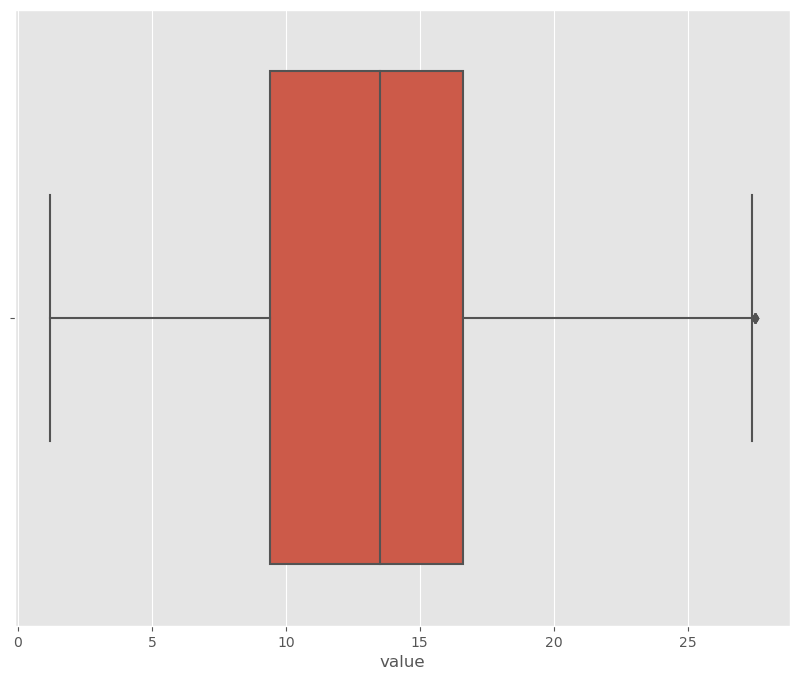

In [38]:
plot_boxplot(newdata_no_outliers, 'value')

#### Heatmap to see the correlation between column

,year,value
year,1.000000,0.069033
value,0.069033,1.000000


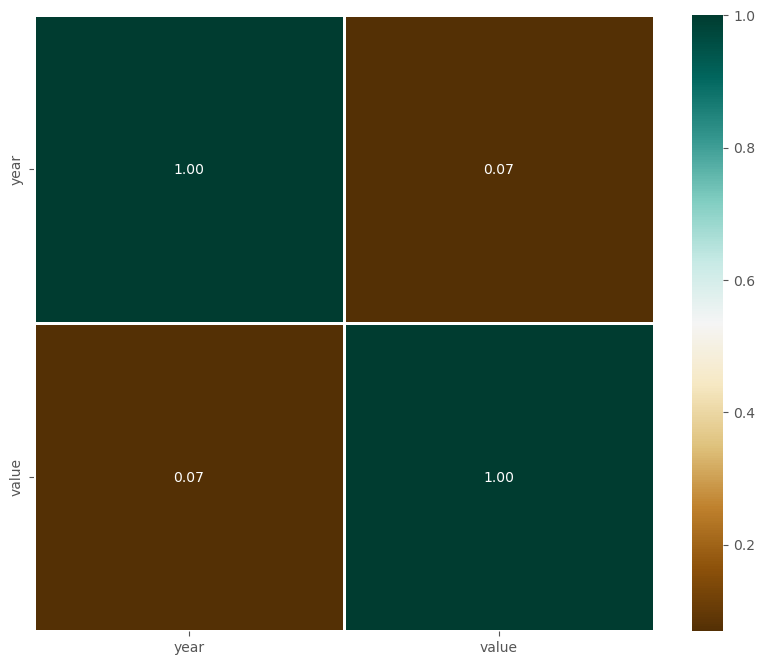

In [39]:
# correlation = population_dataframe.corr()
plt.figure(figsize=(10,8))
correlation = newdata_no_outliers.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, fmt='.2f', linewidths=2, cmap="BrBG")
correlation


#### Shape of Dataset after cleaning

In [40]:
newdata_no_outliers.shape

(3279, 5)

#### Describe new dataset

In [41]:
newdata_no_outliers.describe()

,year,value
count,3279.000000,3279.000000
mean,2016.946020,13.385148
std,3.737311,5.985045
min,2011.000000,1.200000
25%,2014.000000,9.400000
50%,2017.000000,13.500000
75%,2020.000000,16.600000
max,2023.000000,27.500000


#### Subplot

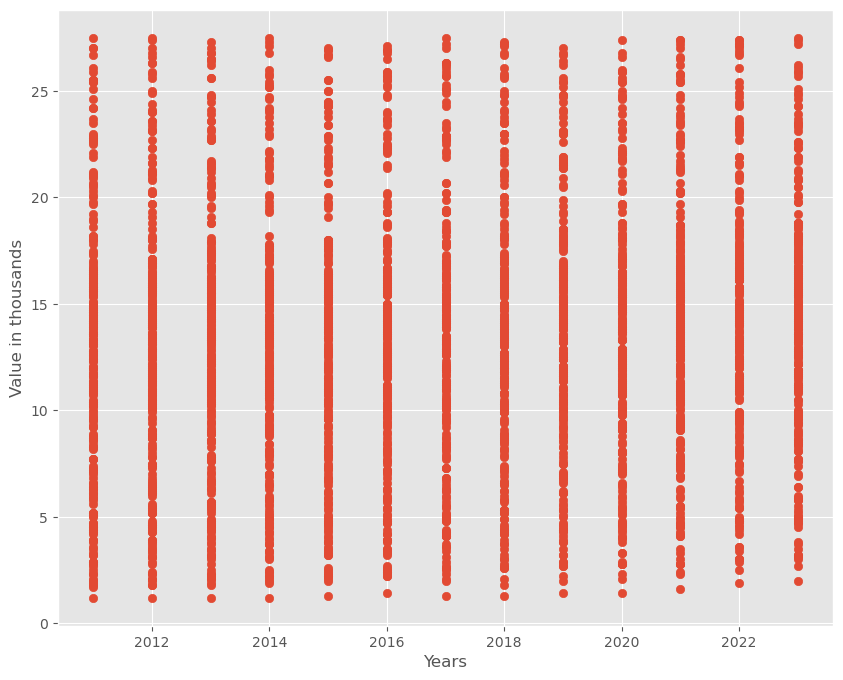

In [42]:
# plot subplots
fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(newdata_no_outliers["year"], newdata_no_outliers["value"])
ax.set_xlabel("Years")
ax.set_ylabel("Value in thousands")
plt.show()

In [43]:
newdata_no_outliers.describe()

,year,value
count,3279.000000,3279.000000
mean,2016.946020,13.385148
std,3.737311,5.985045
min,2011.000000,1.200000
25%,2014.000000,9.400000
50%,2017.000000,13.500000
75%,2020.000000,16.600000
max,2023.000000,27.500000


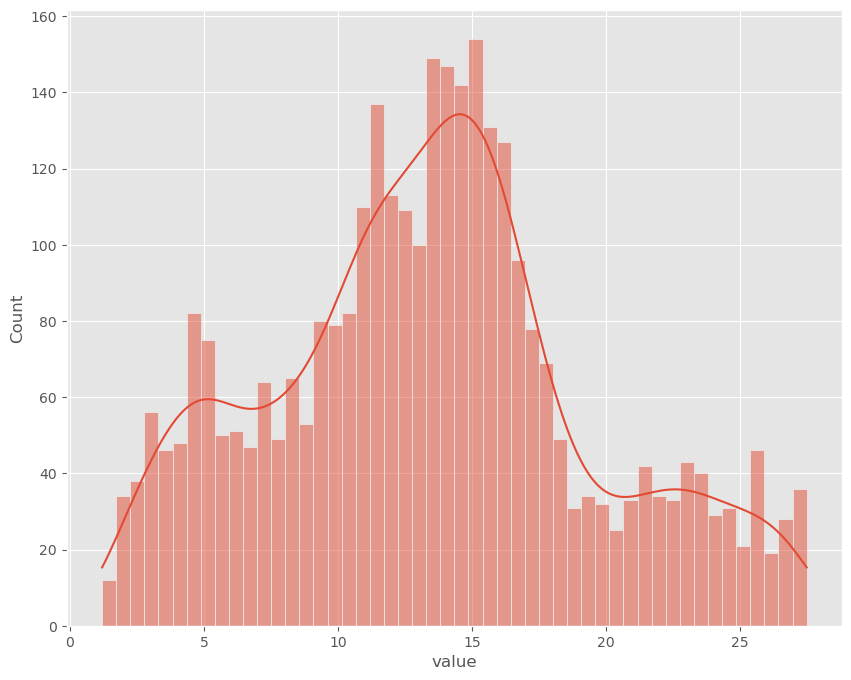

In [45]:
# Histplot explain distribution of data i.e Symmetric distribution  data
plt.figure(figsize=(10,8))
sns.histplot(data=newdata_no_outliers, x='value', kde=True, bins=50);

#### Calculate Skewness for distribution of data

In [46]:
# best skew value should be -3 to +3
skew_value = stats.skew(newdata_no_outliers['value'], axis=0, bias=True)
print('Skew Value',skew_value)

Skew Value 0.21492448926300015


#### Calculate kurtosis for distribution of data

In [47]:
# best kurtosis value should be -10 to +10
kurtosis_value = stats.kurtosis(newdata_no_outliers['value'], axis=0, bias=True)
print('kurtosis Value',kurtosis_value)

kurtosis Value -0.36541790623357784


In [48]:
newdata_no_outliers.describe(include=object)

,age_group,sex,region
count,3279,3279,3279
unique,18,2,8
top,85 years and over,Male,Border
freq,208,1651,468


In [49]:
newdata_no_outliers['age_group'].unique()

array(['0 - 4 years', '5 - 9 years', '10 - 14 years', '15 - 19 years',
       '20 - 24 years', '25 - 29 years', '30 - 34 years', '35 - 39 years',
       '40 - 44 years', '45 - 49 years', '50 - 54 years', '55 - 59 years',
       '60 - 64 years', '65 - 69 years', '70 - 74 years', '75 - 79 years',
       '80 - 84 years', '85 years and over'], dtype=object)

#### Pairplot to see distribution of data from different view

<Figure size 1000x800 with 0 Axes>

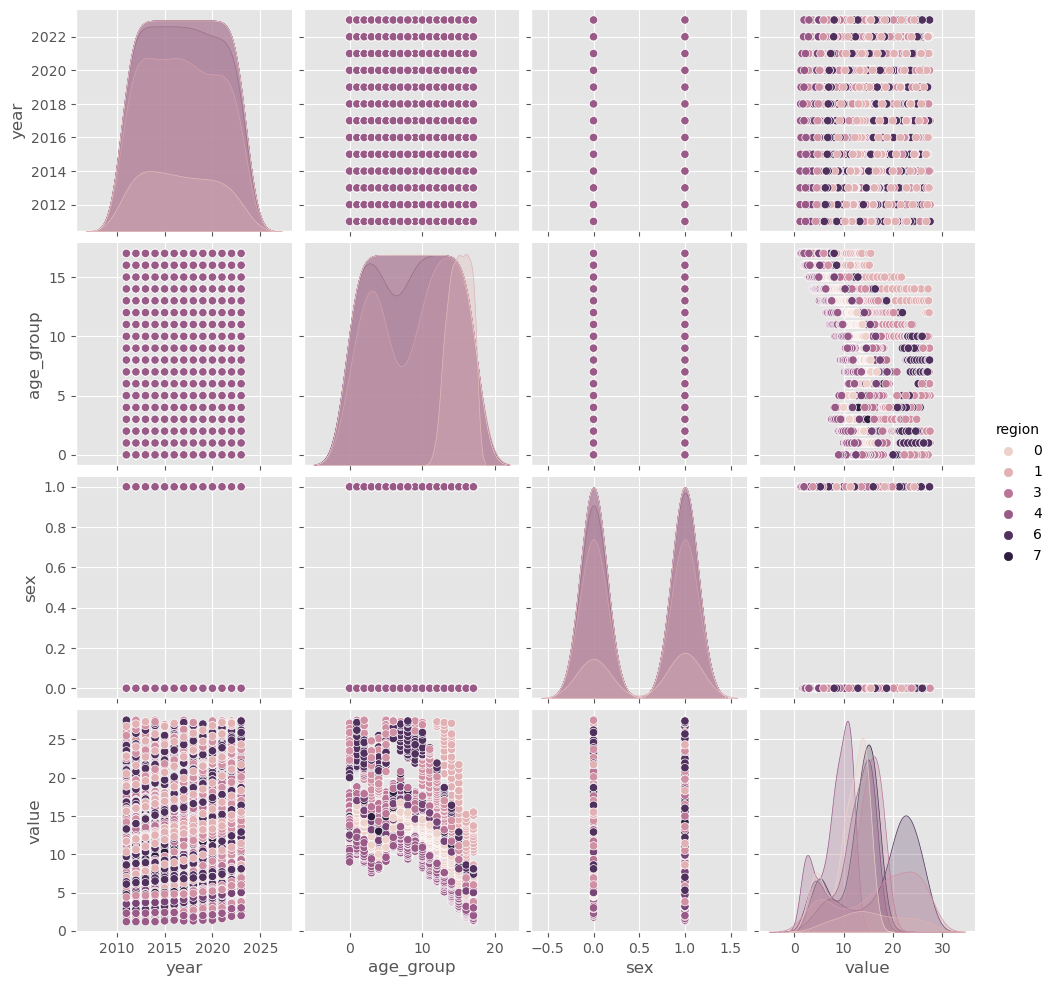

In [123]:
plt.figure(figsize=(10,8));
sns.pairplot(newdata_no_outliers, hue="region");
plt.show()

# Statistical Data Analysis and visualization

### Total population by year of all states from 2011-2023

In [51]:
# Filter population 
all_age_bt_sex_state_df = population_dataframe.loc[(population_dataframe['sex'] == 'Both sexes') & (population_dataframe['region'] == 'State') & (population_dataframe['age_group'] == 'All ages')].reset_index(drop=True)

In [52]:
# Statistical value for bar graph year and population
all_age_bt_sex_state_df[['year','value']]

,year,value
0,2011,4574.9
1,2012,4593.7
2,2013,4614.7
3,2014,4645.4
4,2015,4687.8
5,2016,4739.6
6,2017,4810.9
7,2018,4884.9
8,2019,4958.5
9,2020,5029.9


#### Statistical value  for bar graph

In [53]:
print(f"Max: {all_age_bt_sex_state_df[['year','value']].max()},  Min: {all_age_bt_sex_state_df[['year','value']].min()}, Mean: {all_age_bt_sex_state_df[['year','value']].mean()} ")


Max: year     2023.0
value    5281.6
dtype: float64,  Min: year     2011.0
value    4574.9
dtype: float64, Mean: year     2017.000000
value    4852.353846
dtype: float64 


### Mean

In [54]:
population_mean_value = newdata_no_outliers['value'].mean()
print("Mean Value of Population: ", population_mean_value)

Mean Value of Population:  13.385147910948458


### Stander deviation 

In [55]:
population_std_value = newdata_no_outliers['value'].std()
print("Standard Deviation Value of Population: ", population_std_value)

Standard Deviation Value of Population:  5.985045087974134


#### Bar graph

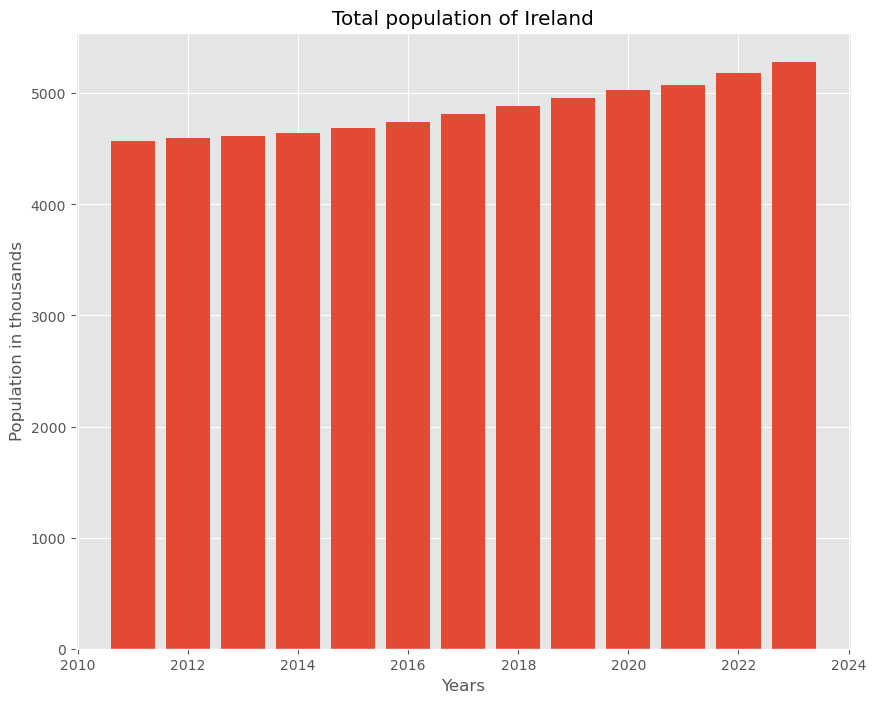

In [56]:
#Bar graph to compare population by year 2011-2023 
plt.figure(figsize=(10,8))
plt.bar(all_age_bt_sex_state_df['year'], all_age_bt_sex_state_df['value'])
plt.title("Total population of Ireland")
plt.ylabel("Population in thousands")
plt.xlabel("Years")
plt.show()

### Child population age 0-4 years, both sex, all states

In [57]:

age04_bt_sex_state_df = population_dataframe.loc[(population_dataframe['sex'] == 'Both sexes') & (population_dataframe['region'] == 'State') & (population_dataframe['age_group'] == '0 - 4 years')].reset_index(drop=True)
age04_bt_sex_state_df

,year,age_group,sex,region,value
0,2011,0 - 4 years,Both sexes,State,356.0
1,2012,0 - 4 years,Both sexes,State,358.2
2,2013,0 - 4 years,Both sexes,State,353.0
3,2014,0 - 4 years,Both sexes,State,345.4
4,2015,0 - 4 years,Both sexes,State,337.9
5,2016,0 - 4 years,Both sexes,State,331.4
6,2017,0 - 4 years,Both sexes,State,325.0
7,2018,0 - 4 years,Both sexes,State,320.0
8,2019,0 - 4 years,Both sexes,State,315.0
9,2020,0 - 4 years,Both sexes,State,308.7


#### Line graph to show birth rate

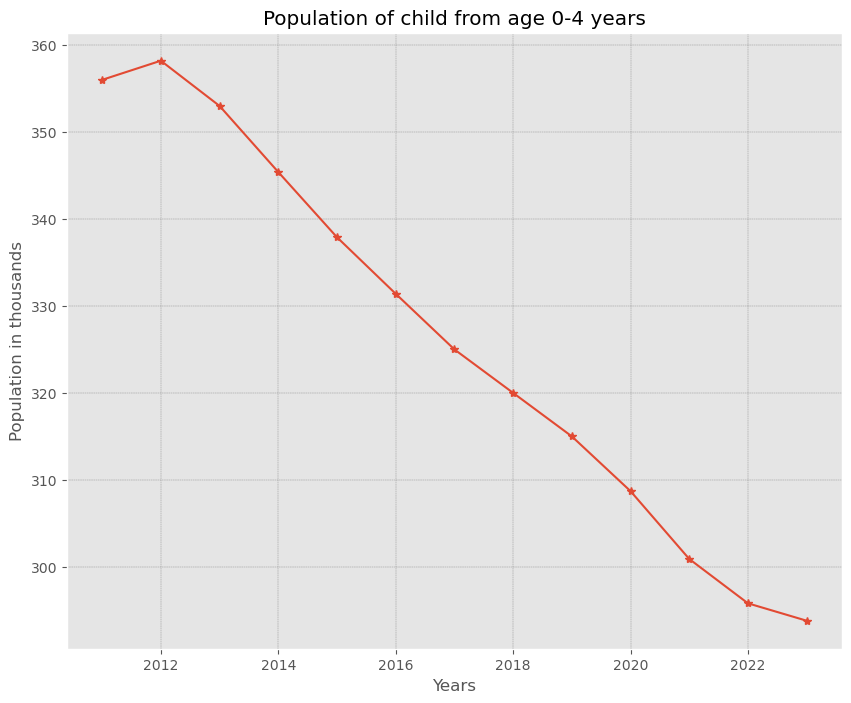

In [58]:
#Bar graph to compare population by year 2011-2023 
plt.figure(figsize=(10,8))
plt.plot(age04_bt_sex_state_df['year'], age04_bt_sex_state_df['value'], marker='*')
plt.title("Population of child from age 0-4 years")
plt.ylabel("Population in thousands")
plt.xlabel("Years")
plt.grid(color = 'grey', linestyle = '--', linewidth = 0.3)
plt.show()

# why child birth is decreasing each year -> research

###  Older Adults Population age 85 years and above , both sex, all states

In [59]:
age85_above_bt_sex_state_df = population_dataframe.loc[(population_dataframe['sex'] == 'Both sexes') & (population_dataframe['region'] == 'State') & (population_dataframe['age_group'] == '85 years and over')].reset_index(drop=True)
age85_above_bt_sex_state_df

,year,age_group,sex,region,value
0,2011,85 years and over,Both sexes,State,58.2
1,2012,85 years and over,Both sexes,State,59.8
2,2013,85 years and over,Both sexes,State,60.7
3,2014,85 years and over,Both sexes,State,62.7
4,2015,85 years and over,Both sexes,State,64.9
5,2016,85 years and over,Both sexes,State,67.3
6,2017,85 years and over,Both sexes,State,69.1
7,2018,85 years and over,Both sexes,State,71.8
8,2019,85 years and over,Both sexes,State,74.1
9,2020,85 years and over,Both sexes,State,75.6


#### Line graph 

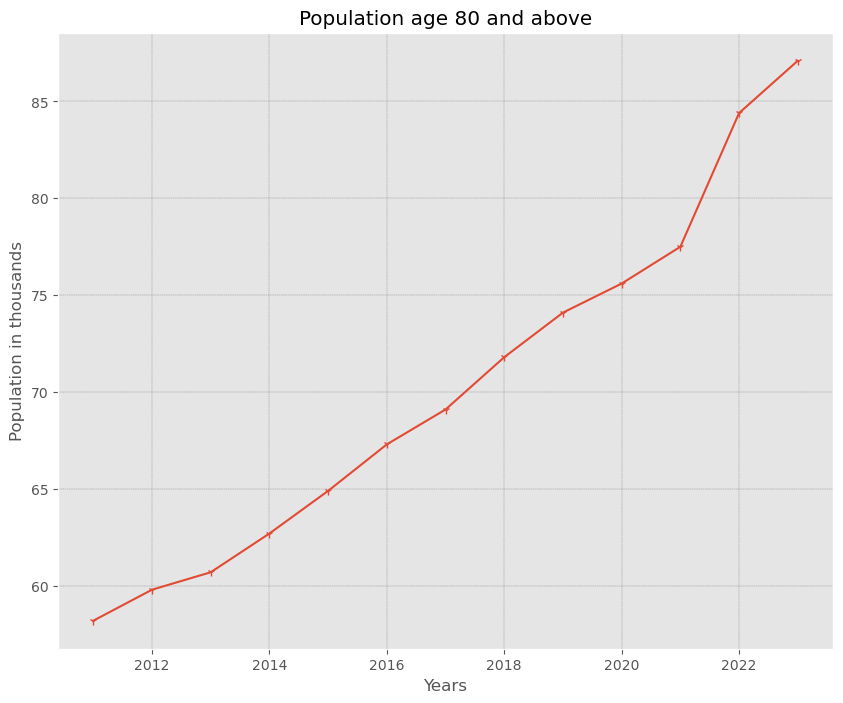

In [121]:
#Bar graph to compare population by year 2011-2023 
plt.figure(figsize=(10,8))
plt.plot(age85_above_bt_sex_state_df['year'], age85_above_bt_sex_state_df['value'], marker='1')
plt.title("Population age 80 and above")
plt.ylabel("Population in thousands")
plt.xlabel("Years")
plt.grid(color = 'grey', linestyle = '--', linewidth = 0.3)
plt.show()

#### Define Class with method get_age_data() to get data frame based on  different age group

In [61]:
# Define class name PopulationByAgeGroup
class PopulationByAgeGroup:
    
    # __init__() is Constructor: The function that runs whenever we make a new object i.e population_data 
    def __init__(self, population_dataframe):
        self.population_dataframe = population_dataframe
        
        #gives uniques all age group
        self.age_group_only = population_dataframe['age_group'].unique()
        print('All age group: ',self.age_group_only)
        
    def get_age_data(self, start_age, end_age, sex, region):
        age_group_years = self.age_group_only[start_age: end_age]
        print('age_group_years',age_group_years)

        # find either value from different age exist or not 
        has_age_group = population_dataframe['age_group'].isin(age_group_years)
        
        # filter data age lies from '15 - 19 years' to  '60 - 64 years'
        filter_age_group_df = (population_dataframe.loc[has_age_group])
        age_group_df = filter_age_group_df.loc[(filter_age_group_df['sex'] == sex) & (filter_age_group_df['region'] == region)]
        age_group_df = age_group_df.groupby(['year']).sum().reset_index()
        return age_group_df


# Initilization of Class PopulationByAgeGroup
population_data = PopulationByAgeGroup(population_dataframe)

All age group:  ['0 - 4 years' '5 - 9 years' '10 - 14 years' '15 - 19 years'
 '20 - 24 years' '25 - 29 years' '30 - 34 years' '35 - 39 years'
 '40 - 44 years' '45 - 49 years' '50 - 54 years' '55 - 59 years'
 '60 - 64 years' '65 - 69 years' '70 - 74 years' '75 - 79 years'
 '80 - 84 years' '85 years and over' 'All ages']


### Working population in ireland age 15-64

In [62]:
# get dataframe of age group from '15 - 19 years' to  '60 - 64 years'
# Call PopulationByAgeGroup
working_age_data = population_data.get_age_data(start_age = 3, end_age= 13, sex='Both sexes', region='State')
print('Woring population in Ireland by year : \n',working_age_data)


age_group_years ['15 - 19 years' '20 - 24 years' '25 - 29 years' '30 - 34 years'
 '35 - 39 years' '40 - 44 years' '45 - 49 years' '50 - 54 years'
 '55 - 59 years' '60 - 64 years']
Woring population in Ireland by year : 
     year   value
0   2011  3066.6
1   2012  3055.7
2   2013  3051.5
3   2014  3058.5
4   2015  3075.9
5   2016  3104.3
6   2017  3148.1
7   2018  3194.0
8   2019  3241.6
9   2020  3290.1
10  2021  3319.7
11  2022  3388.2
12  2023  3463.7


#### Line graph

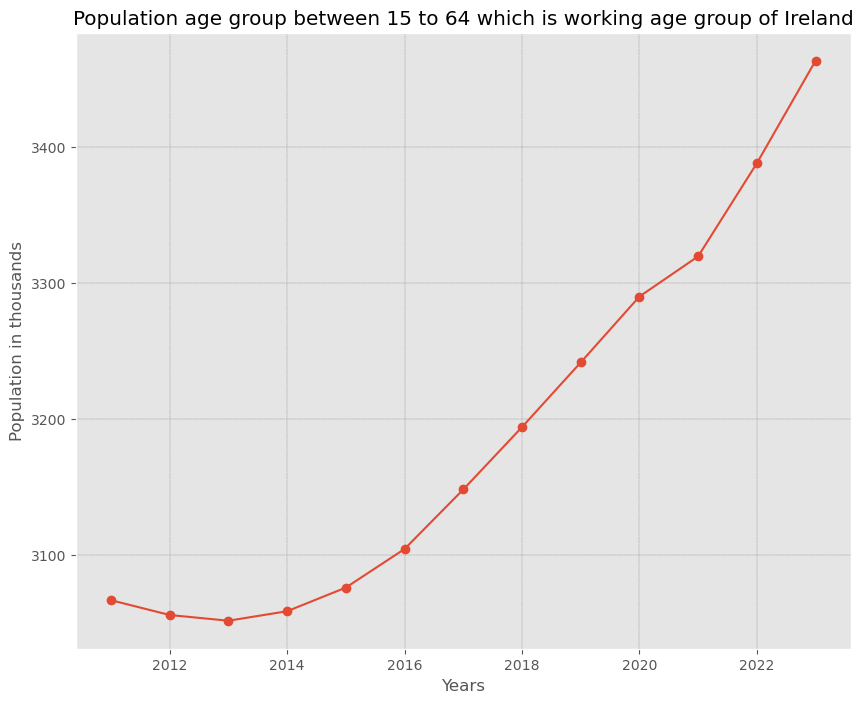

In [63]:
# function to plot line chart to show trend of population based on age group
def plot_linegraph(data_frame, title,  marker_icon):
    plt.figure(figsize=(10,8))
    plt.plot(data_frame['year'], data_frame['value'], marker=marker_icon)
    plt.title(title)
    plt.ylabel("Population in thousands")
    plt.xlabel("Years")
    plt.grid(color = 'grey', linestyle = '--', linewidth = 0.3)
    plt.show()
    
# line plot showing trend of working populatin in ireland by years
plot_linegraph(working_age_data, "Population age group between 15 to 64 which is working age group of Ireland", "o")

### Children population in ireland age range  '0 - 4 years' to '15 - 19 years'

In [64]:
# get dataframe of age group from '0-4 years' to  '10 - 14 years'
# Call PopulationByAgeGroup
children_age_data = population_data.get_age_data(start_age = 0, end_age= 3, sex='Both sexes', region='State')
print('Children population in Ireland by year : \n',children_age_data)


age_group_years ['0 - 4 years' '5 - 9 years' '10 - 14 years']
Children population in Ireland by year : 
     year   value
0   2011   976.6
1   2012   988.0
2   2013   993.9
3   2014   997.6
4   2015  1001.6
5   2016  1005.6
6   2017  1010.4
7   2018  1014.4
8   2019  1015.6
9   2020  1013.6
10  2021  1007.6
11  2022  1014.3
12  2023  1011.6


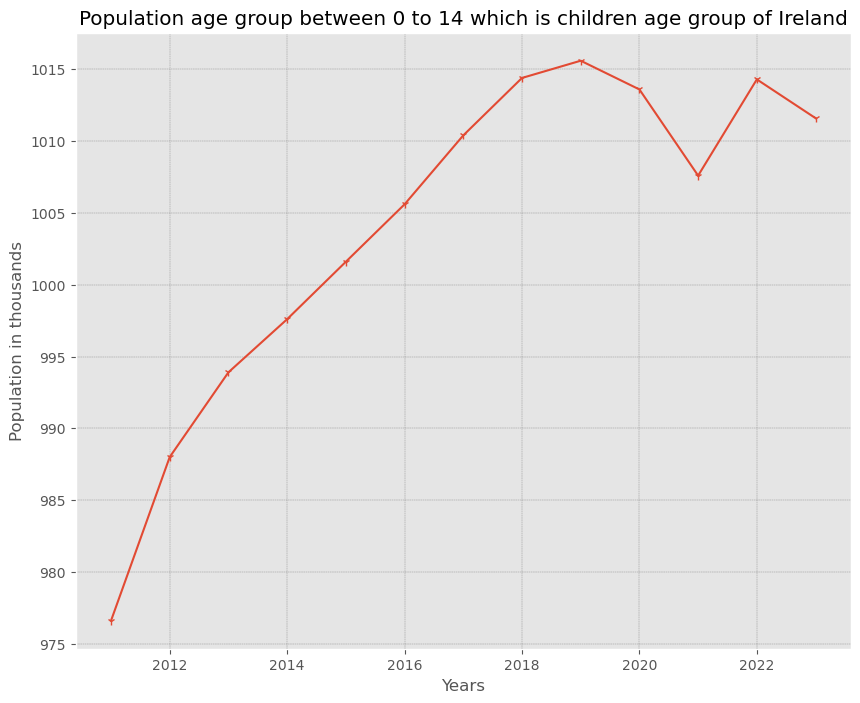

In [65]:
# line plot showing trend of working populatin in ireland by years
plot_linegraph(children_age_data, "Population age group between 0 to 14 which is children age group of Ireland", "1")

### Older age population in ireland age range 65 and above

In [66]:
# Call PopulationByAgeGroup
older_age_data = population_data.get_age_data(start_age = 13, end_age= -1, sex='Both sexes', region='State')
print('Older population in Ireland by year : \n',working_age_data)

age_group_years ['65 - 69 years' '70 - 74 years' '75 - 79 years' '80 - 84 years'
 '85 years and over']
Older population in Ireland by year : 
     year   value
0   2011  3066.6
1   2012  3055.7
2   2013  3051.5
3   2014  3058.5
4   2015  3075.9
5   2016  3104.3
6   2017  3148.1
7   2018  3194.0
8   2019  3241.6
9   2020  3290.1
10  2021  3319.7
11  2022  3388.2
12  2023  3463.7


### Chart data for Children, Working age and Older age for year 2023

In [67]:
chart_data_frame = [children_age_data, working_age_data, older_age_data]
chart_data_frame = pd.concat([children_age_data['year'], children_age_data['value'], working_age_data['value'], older_age_data['value']], keys=['year','children','working','older'], axis=1).reset_index(drop=True)
chart_data_frame

,year,children,working,older
0,2011,976.6,3066.6,531.6
1,2012,988.0,3055.7,549.9
2,2013,993.9,3051.5,569.2
3,2014,997.6,3058.5,589.5
4,2015,1001.6,3075.9,610.3
5,2016,1005.6,3104.3,629.9
6,2017,1010.4,3148.1,652.4
7,2018,1014.4,3194.0,676.5
8,2019,1015.6,3241.6,701.3
9,2020,1013.6,3290.1,726.1


In [68]:
chart_data_frame = chart_data_frame[chart_data_frame['year'] == 2023].reset_index(drop=True)
chart_data_frame

,year,children,working,older
0,2023,1011.6,3463.7,806.3


#### Pie chart to show children, older, and working population

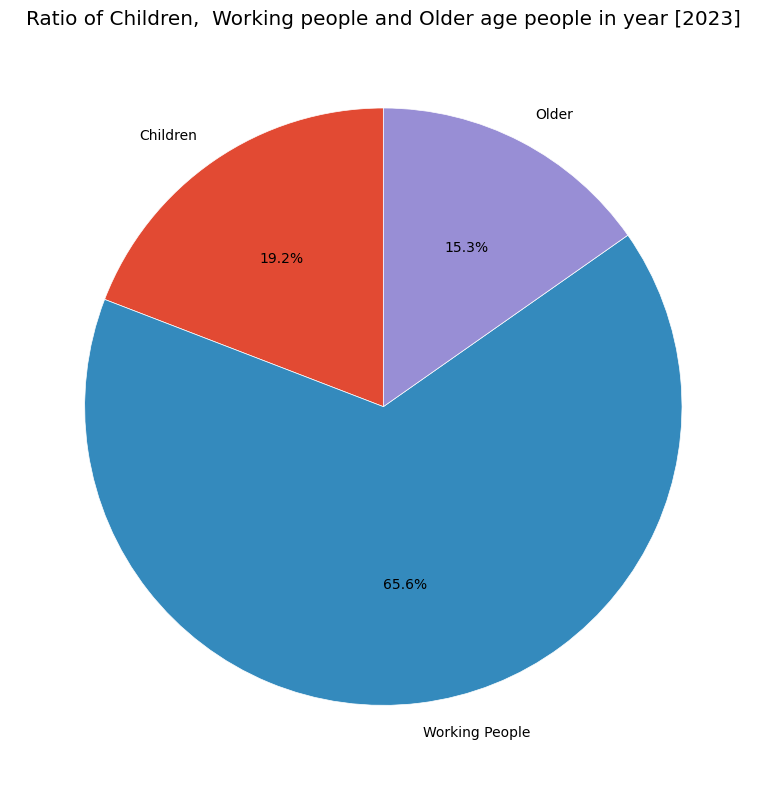

In [69]:
pie_data = chart_data_frame.iloc[:,1:].values.flatten()
years = chart_data_frame.iloc[:, 0].values
plt.figure(figsize=(10,8))
plt.pie(pie_data, labels=['Children', 'Working People', 'Older'], shadow=False, startangle=90, autopct='%1.1f%%', wedgeprops={'edgecolor': '#ffffff'} )
plt.title(f'Ratio of Children,  Working people and Older age people in year {years}')
plt.tight_layout()
plt.show()

## Male and Female population in Each state of Ireland 

In [70]:
class MaleFemalePopulationAnalysis:
    def __init__(self, population_dataframe, year, age_group = 'All ages'):
        self.population_dataframe = population_dataframe
        self.year = year
        self.age_group = age_group
        
        #filter male and female data based on year
        self.filter_year_d = (population_dataframe['year'] == self.year) & (population_dataframe['age_group'] == self.age_group) & (population_dataframe['sex'] != 'Both sexes') & (population_dataframe['region'] != 'State')
        self.filter_year_data = population_dataframe.loc[self.filter_year_d].reset_index()
        
        # Filter for Male data
        self.male_value = (self.filter_year_data[self.filter_year_data['sex'] == 'Male'])['value'].values

        # Filter for Female data
        self.female_value = (self.filter_year_data[self.filter_year_data['sex'] == 'Female'])['value'].values

        # Get all region
        self.all_region = self.filter_year_data['region'].unique()

        self.gender_dict = {
            'Male': np.array(self.male_value),
            'Female': np.array(self.female_value)
        }
        
        self.male_percentage = []
        self.female_percentage = []
        for i in range(len(self.male_value)):
            sums = self.male_value[i] + self.female_value[i]
            self.male_percentage.append(np.round((self.male_value[i]/sums)*100,2))
            self.female_percentage.append(np.round((self.female_value[i]/sums)*100,2))
  
        
    def get_male_female_stack_bar(self):
           
        bottom = np.zeros(len(self.all_region))
        labels={}
    
        fig, ax = plt.subplots(figsize=(10, 8))
        for gender, value in self.gender_dict.items():
            percentages = self.male_percentage if gender == 'Male' else self.female_percentage
            per_values = [f'{v} \n ({p}%)' for v,p in zip(value, percentages)]
            labels = per_values
            bar_container = ax.bar(self.all_region, value, width=0.8, label=gender, bottom=bottom)
            bottom += value
            ax.bar_label(bar_container, label_type='center', color='w', labels=labels, padding=0)
            
        ax.set_title(f"Male and Female Population of Ireland  in each Region {self.year}")
        ax.legend(loc="upper right")
        plt.xlabel("States")
        plt.ylabel("Populations in Thousands")
        plt.show()
     
    
    def get_male_female_line_graph(self, marker_icon, title="Male and Female Population of Ireland  in each Region"):
        plt.figure(figsize=(10,8))
        for gender, value in self.gender_dict.items():
            plt.plot(self.all_region, value, label= gender, marker=marker_icon)
            
        plt.title(f"{title} {self.year}")
        plt.legend()
        plt.grid(color = 'grey', linestyle = '--', linewidth = 0.3)
        plt.xlabel("States")
        plt.ylabel("Populations in Thousands")
        plt.show()

        
# Initialize call MaleFemalePopulationAnalysis
# Data of 2011
male_female_pop_bar_2011 = MaleFemalePopulationAnalysis(population_dataframe, 2011)  
male_female_pop_line_2011 = MaleFemalePopulationAnalysis(population_dataframe, 2011)

# Data of 2023
male_female_pop_bar_2023 = MaleFemalePopulationAnalysis(population_dataframe, 2023)  
male_female_pop_line_2023 = MaleFemalePopulationAnalysis(population_dataframe, 2023)

# Data of Male and Female age 0-4 years
male_female_04_years = MaleFemalePopulationAnalysis(population_dataframe, 2023, age_group='0 - 4 years')


#### Line chart to show Male and Female population in each state of Ireland in Year 2011

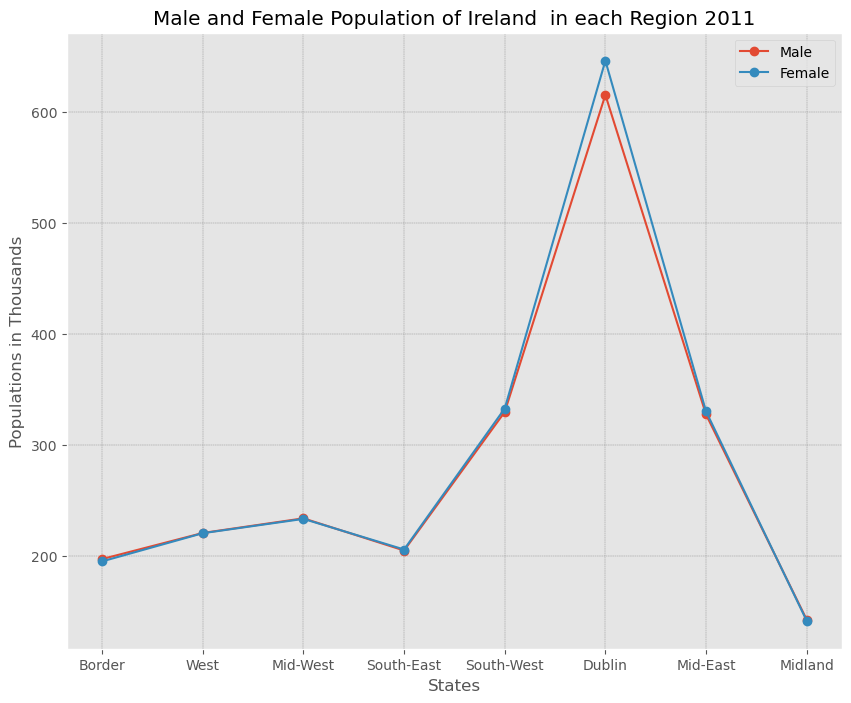

In [71]:
# Line graph
male_female_pop_line_2011.get_male_female_line_graph(marker_icon='o')


#### Stacked bar chart to show Male and Female population in each state of Ireland in Year 2011

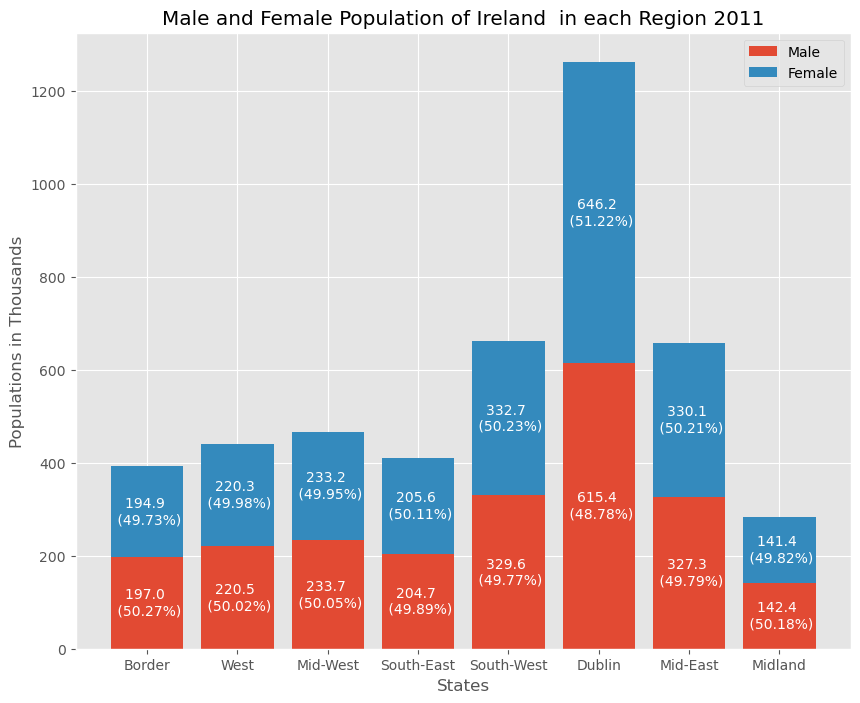

In [72]:
# Call method get_male_female_stack_bar() from class MaleFemalePopulationAnalysis

male_female_pop_bar_2011.get_male_female_stack_bar()

#### Line chart to show 0-4 Year of Male and Female population  in each state of Ireland in Year 2023

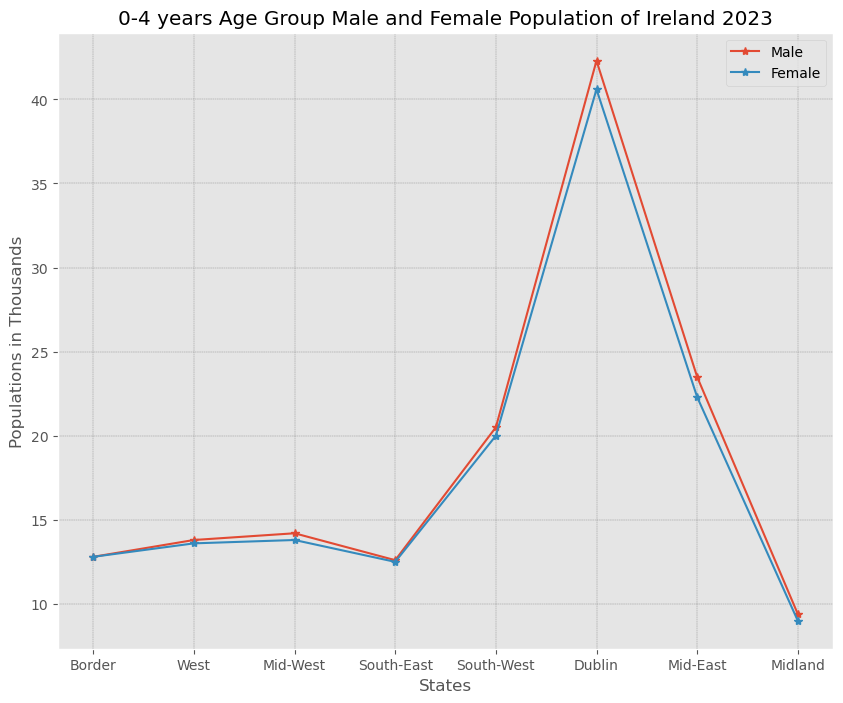

In [73]:
male_female_04_years.get_male_female_line_graph(title="0-4 years Age Group Male and Female Population of Ireland", marker_icon='*')

#### Stacked bar chart to show Male and Female population in each state of Ireland in Year 2023

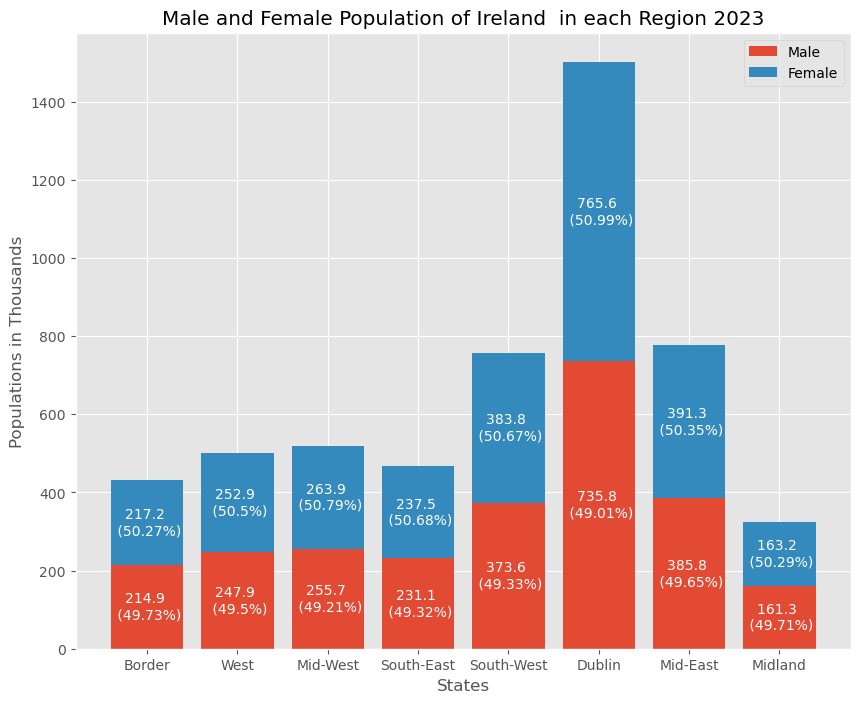

In [74]:
male_female_pop_bar_2023.get_male_female_stack_bar()

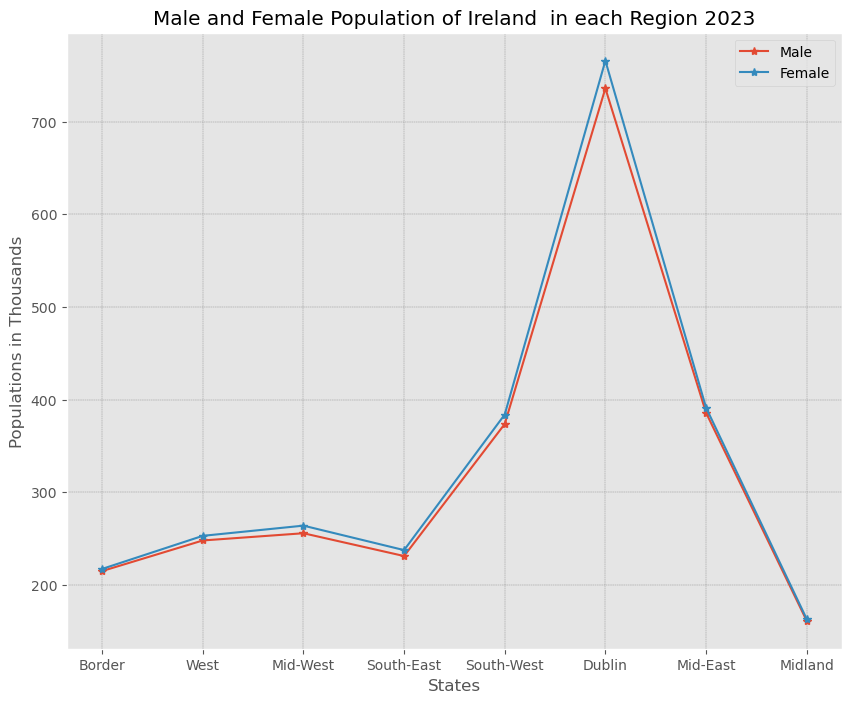

In [75]:
male_female_pop_line_2023.get_male_female_line_graph(marker_icon='*')

#### Encoding data 

In [76]:
# calling the method from preprocessing class and assign into variable
ord_encoder = OrdinalEncoder()             # Ordinal Data
lab_encoder = LabelEncoder()               # Label Data or Nominal Data
cat_encoder = OneHotEncoder(sparse=False)  # Categorical Data | Nominal

# assign data frame to new variable encoded_data_frame
encoded_data_frame = newdata_no_outliers

In [77]:
encoded_data_frame['age_group'] = ord_encoder.fit_transform(encoded_data_frame[['age_group']])
encoded_data_frame['sex'] = lab_encoder.fit_transform(encoded_data_frame['sex'])
encoded_data_frame['region'] = lab_encoder.fit_transform(encoded_data_frame['region'])
encoded_data_frame.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 3279 entries, 0 to 3743
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       3279 non-null   int64  
 1   age_group  3279 non-null   float64
 2   sex        3279 non-null   int64  
 3   region     3279 non-null   int64  
 4   value      3279 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 153.7 KB


## Statistic Graph

### Normal Distribution

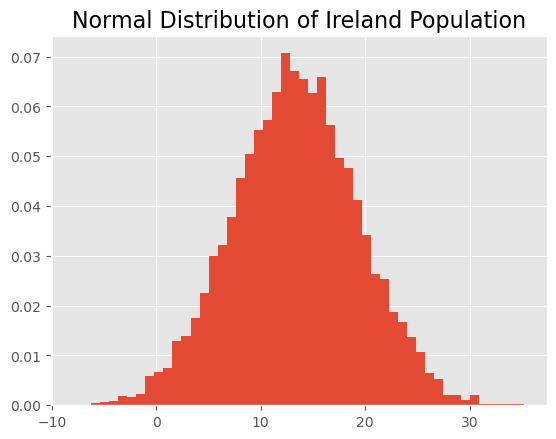

<Figure size 1000x800 with 0 Axes>

In [78]:
# Normal Distribution 
# Mean and Standard Deviation of the population are calculated above

n = np.random.normal(population_mean_value, population_std_value, size=10000)
count, bins, ignored = plt.hist(n, 50, density=True)
plt.title("Normal Distribution of Ireland Population", fontsize=16)
plt.figure(figsize=(10,8))
plt.show()




#### Normal distribution in line graph

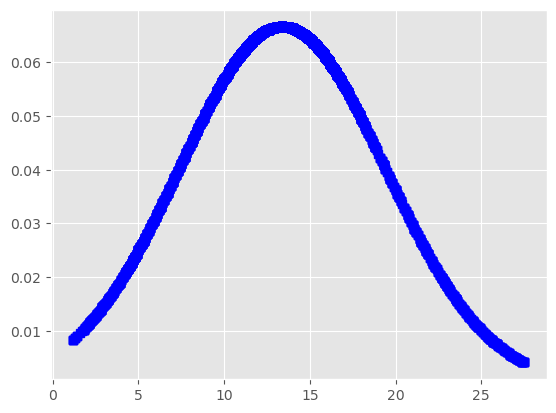

<Figure size 1000x800 with 0 Axes>

In [79]:
normal_df = stats.norm.pdf(newdata_no_outliers['value'], loc=population_mean_value, scale=population_std_value)
plt.plot(newdata_no_outliers['value'], normal_df, 'bs')
plt.figure(figsize=(10,8))
plt.show()


### Poisson Distribution for Population 

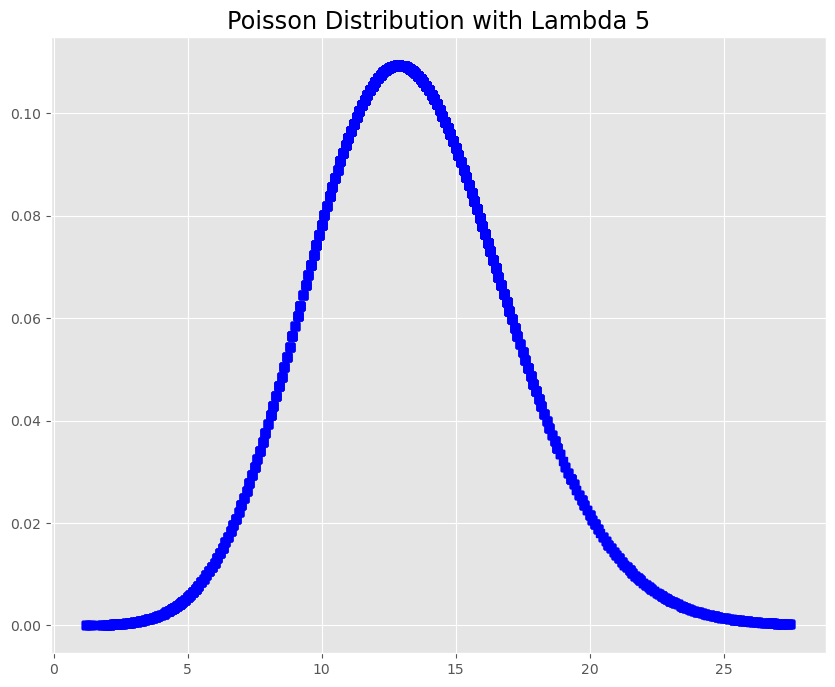

In [80]:

def plot_poisson_distribution(column_value):
    x=pd.Series(column_value).to_numpy()
    y=np.exp(-column_value.mean()) * np.power(column_value.mean(),x)/factorial(x)
    plt.figure(figsize=(10,8))
    plt.title("Poisson Distribution with Lambda 5", fontsize="xx-large")
    plt.plot(x,y,'bs')
    plt.show()

# call function
plot_poisson_distribution(encoded_data_frame['value'])

#### Describe Encoded dataset

In [81]:
encoded_data_frame.describe()

,year,age_group,sex,region,value
count,3279.000000,3279.000000,3279.000000,3279.000000,3279.000000
mean,2016.946020,8.842330,0.503507,3.791095,13.385148
std,3.737311,5.287681,0.500064,2.268164,5.985045
min,2011.000000,0.000000,0.000000,0.000000,1.200000
25%,2014.000000,4.000000,0.000000,2.000000,9.400000
50%,2017.000000,9.000000,1.000000,4.000000,13.500000
75%,2020.000000,14.000000,1.000000,6.000000,16.600000
max,2023.000000,17.000000,1.000000,7.000000,27.500000


### Poisson Distribution for Age group 

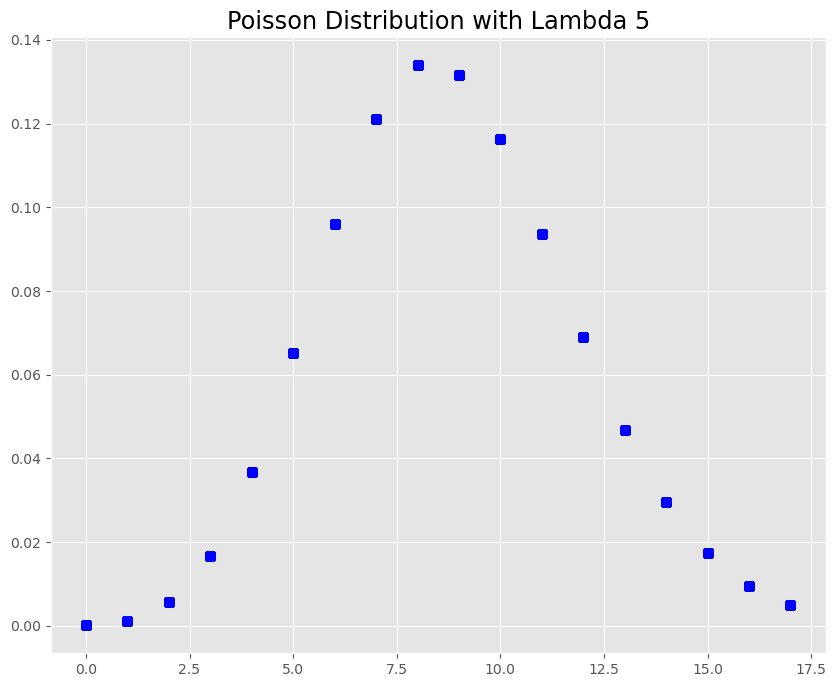

In [82]:
# call poission distribution function
plot_poisson_distribution(encoded_data_frame['age_group'])

# Machine Learning Models

### We have encoded dataframe for labeled i.e Nominal, ordinal i.e Ordered data

In [83]:
encoded_data_frame.head()

,year,age_group,sex,region,value
0,2011,0.0,1,0,15.8
1,2011,0.0,1,7,16.6
2,2011,0.0,1,3,18.0
3,2011,0.0,1,5,16.4
4,2011,0.0,1,6,25.5


In [84]:
encoded_data_frame.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3279 entries, 0 to 3743
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       3279 non-null   int64  
 1   age_group  3279 non-null   float64
 2   sex        3279 non-null   int64  
 3   region     3279 non-null   int64  
 4   value      3279 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 153.7 KB


### Scaling Data i.e Standarization because data has high outliers and data is Gussian distributed

In [85]:
scalar = StandardScaler() # Creating object of class StandardScaler() from sklearn.preprocessing 
encoded_data_frame = pd.DataFrame(scalar.fit_transform(encoded_data_frame), columns=encoded_data_frame.columns)
encoded_data_frame.shape

(3279, 5)

In [86]:
encoded_data_frame.head() # Here after standarization values scaled -1 to 1

,year,age_group,sex,region,value
0,-1.591231,-1.672506,0.99301,-1.671692,0.403543
1,-1.591231,-1.672506,0.99301,1.414974,0.537229
2,-1.591231,-1.672506,0.99301,-0.348835,0.771181
3,-1.591231,-1.672506,0.99301,0.533070,0.503808
4,-1.591231,-1.672506,0.99301,0.974022,2.024496


In [87]:
encoded_data_frame.shape

(3279, 5)

#### Seperating dataset for training and testing

In [88]:
X = encoded_data_frame.drop(['value'], axis=1)
y = encoded_data_frame['value']

#### Selection of best random_state

In [89]:
def get_best_random_state(X,y):
    best_random_state = None
    
    best_training_accuracy = 0.0
    best_testing_accuracy = 0.0
    
    random_state_range = [*range(1,101)] # list bwtween 1-100
    
    for rndom_state in random_state_range:
        #Split data
        X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=rndom_state)
    
        #Initializing and training ML model
        Ml_Model = LinearRegression()
        Ml_Model.fit(X_train, y_train)
        
        # train score
        train_score = Ml_Model.score(X_train,y_train)
        
        #test score
        test_score = Ml_Model.score(X_test,y_test)        

        # check if random_state value give best performance
        if (test_score > best_testing_accuracy):
            best_training_accuracy = train_score
            best_testing_accuracy = test_score
            best_random_state = rndom_state

    print(f'Best Training Accuracy: {round(best_training_accuracy*100,3)}%')
    print(f'Best Testing Accuracy: {round(best_testing_accuracy*100,3)}%')
    print(f'Best random state : {best_random_state}')
    return best_random_state
    
best_random_state = get_best_random_state(X,y)   

Best Training Accuracy: 29.582%
Best Testing Accuracy: 35.934%
Best random state : 56


#### Display training and testing data shape

In [90]:
# selecting random_state = 78 from above test

#Split data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=best_random_state)
print('X_train:',X_train.shape)
print('X_test:',X_test.shape)
print('y_train:',y_train.shape)
print('y_test:',y_test.shape)

X_train: (2623, 4)
X_test: (656, 4)
y_train: (2623,)
y_test: (656,)


## Applying Machine Learning model

### Linear Regression 

In [91]:
linear_reg_model = LinearRegression()

# fin an OLS model
linear_reg_model.fit(X_train,y_train) 

LinearRegression()

In [92]:
# Make Prediction
y_predict_train = linear_reg_model.predict(X_train)
y_predict_test = linear_reg_model.predict(X_test)

linear_reg_model.predict([[2024,7.0,1,3]])

array([102.10451123])

##### Linear regression score

In [93]:
print("R-squared of the model in Training set is: {}%\n".format(round(linear_reg_model.score(X_train,y_train)*100,3)))
print("*****Statistical Value for Test Model*****\n")
print("R-squared of the model in Test set is: {}%".format(round(linear_reg_model.score(X_test,y_test)*100,3)))
print("Root mean squared error of the prediction is: {}%".format(round(rmse(y_test,y_predict_test)*100,3)))
print("Mean absolute percentage error of the prediction is: {}%".format(round(np.mean(np.abs((y_test - y_predict_test)/ y_test))*100,3)))

R-squared of the model in Training set is: 29.582%

*****Statistical Value for Test Model*****

R-squared of the model in Test set is: 35.934%
Root mean squared error of the prediction is: 81.942%
Mean absolute percentage error of the prediction is: 312.179%


### Ridge Regression  

In [94]:
### Using GridSearchCV for parameter optimization
ridge_regression = GridSearchCV(Ridge(), param_grid={'alpha': [0.01,0.1,5,42,100]}, verbose=1)
ridge_regression.fit(X_train, y_train)
ridge_value = ridge_regression.best_estimator_

Fitting 5 folds for each of 5 candidates, totalling 25 fits


In [95]:
# Make prediction 
y_ridge_pridct_train = ridge_value.predict(X_train)
y_ridge_pridct_test = ridge_value.predict(X_test)

#### Ridge Regression  Score

In [96]:
print("R-squared of the model in Training set is: {}%\n".format(round(ridge_value.score(X_train,y_train)*100,3)))
print("*****Statistical Value for Test Model*****\n")
print("R-squared of the model in Test set is: {}%".format(round(ridge_value.score(X_test,y_test)*100,3)))
print("Root mean squared error of the prediction is: {}%".format(round(rmse(y_test,y_ridge_pridct_test)*100,3)))
print("Mean absolute percentage error of the prediction is: {}%".format(round(np.mean(np.abs((y_test - y_ridge_pridct_test)/ y_test))*100,3)))

R-squared of the model in Training set is: 29.582%

*****Statistical Value for Test Model*****

R-squared of the model in Test set is: 35.933%
Root mean squared error of the prediction is: 81.942%
Mean absolute percentage error of the prediction is: 312.17%


### Lasso Regression 

In [97]:
### Using GridSearchCV for parameter optimization
lasso_regression = GridSearchCV(Lasso(), param_grid={'alpha': [0.01,0.1,5,42,100]}, verbose=1)
lasso_regression.fit(X_train, y_train)
lasso_value = lasso_regression.best_estimator_

Fitting 5 folds for each of 5 candidates, totalling 25 fits


In [98]:
# Make prediction 
y_lasso_pridct_train = lasso_value.predict(X_train)
y_lasso_pridct_test = lasso_value.predict(X_test)

#### Lasso Regression Score

In [99]:
print("R-squared of the model in Training set is: {}%\n".format(round(lasso_value.score(X_train,y_train)*100,3)))
print("*****Statistical Value for Test Model*****\n")
print("R-squared of the model in Test set is: {}%".format(round(lasso_value.score(X_test,y_test)*100,3)))
print("Root mean squared error of the prediction is: {}%".format(round(rmse(y_test,y_lasso_pridct_test)*100,3)))
print("Mean absolute percentage error of the prediction is: {}%".format(round(np.mean(np.abs((y_test - y_lasso_pridct_test)/ y_test))*100,3)))

R-squared of the model in Training set is: 29.551%

*****Statistical Value for Test Model*****

R-squared of the model in Test set is: 35.573%
Root mean squared error of the prediction is: 82.172%
Mean absolute percentage error of the prediction is: 304.853%


### Decision Tree Regressor

In [100]:
# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=get_best_random_state(X,y))

Best Training Accuracy: 29.582%
Best Testing Accuracy: 35.934%
Best random state : 56


#### Fit data to model for training 

In [101]:
DTRegressor = DecisionTreeRegressor()
DTRegressor.fit(X_train,y_train)

DecisionTreeRegressor()

#### Predict test data

In [102]:
# Make prediction
y_DT_predict_test = DTRegressor.predict(X_test)

In [103]:
##### Decision Tress Regressor Score
print("R-squared of the model in Training set is: {}%\n".format(round(DTRegressor.score(X_train,y_train)*100,3)))
print("*****Statistical Value for Test Model*****\n")
print("R-squared of the model in Test set is: {}%".format(round(DTRegressor.score(X_test,y_test)*100,3)))
print("Mean squared error of the prediction is: {}%".format(round(mse(y_test,y_DT_predict_test)*100,3)))
print("Mean absolute percentage error of the prediction is: {}%".format(round(np.mean(np.abs((y_test - y_DT_predict_test)/ y_test))*100,3)))

R-squared of the model in Training set is: 100.0%

*****Statistical Value for Test Model*****

R-squared of the model in Test set is: 98.398%
Mean squared error of the prediction is: 1.679%
Mean absolute percentage error of the prediction is: 34.324%


### Random Forst Regressor

In [104]:
# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=get_best_random_state(X,y))

Best Training Accuracy: 29.582%
Best Testing Accuracy: 35.934%
Best random state : 56


In [105]:
RFRegressor = RandomForestRegressor()
RFRegressor.fit(X_train,y_train)

RandomForestRegressor()

In [106]:
# Make prediction
y_RF_predict_test = RFRegressor.predict(X_test)

In [107]:
##### Decision Tress Regressor Score
print("R-squared of the model in Training set is: {}%\n".format(round(RFRegressor.score(X_train,y_train)*100,3)))
print("*****Statistical Value for Test Model*****\n")
print("R-squared of the model in Test set is: {}%".format(round(RFRegressor.score(X_test,y_test)*100,3)))
# print("R-squared of the model in Test set is: {}%".format(round(r2_score(y_test, y_RF_predict_test)*100,3)))
print("Mean squared error of the prediction is: {}%".format(round(mse(y_test,y_RF_predict_test)*100,3)))
print("Mean absolute percentage error of the prediction is: {}%".format(round(np.mean(np.abs((y_test - y_RF_predict_test)/ y_test))*100,3)))

R-squared of the model in Training set is: 99.911%

*****Statistical Value for Test Model*****

R-squared of the model in Test set is: 99.307%
Mean squared error of the prediction is: 0.726%
Mean absolute percentage error of the prediction is: 29.956%


### ElasticNet

In [108]:
# Train Model
elastic_net = ElasticNet(alpha=1)
elastic_net.fit(X_train, y_train)

# Calculate the Prediction
y_elastic_predict_train = elastic_net.predict(X_train)
y_elastic_predict_test = elastic_net.predict(X_test)

# Calculate Mean square error 
mean_square_error = np.mean((y_elastic_predict_test- y_test)**2)

# Display Mean Square Error
print("Mean Square Error:", mean_square_error)

Mean Square Error: 1.0182020487779306


#### Display graph for testing and training data

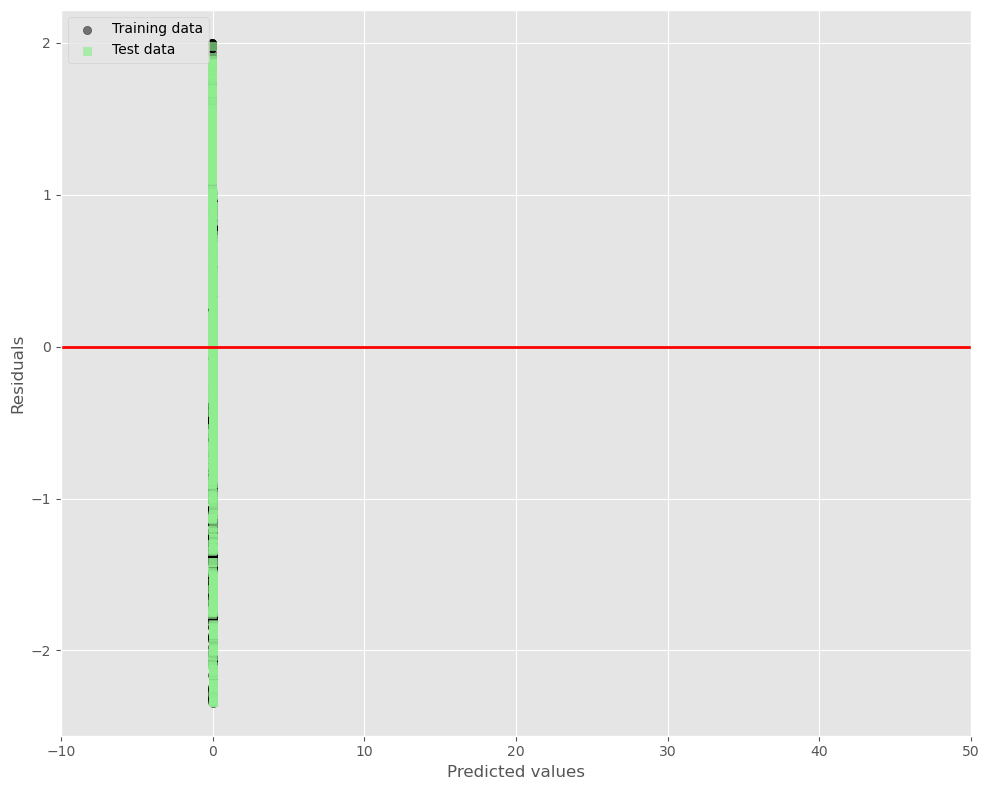

In [109]:
# Draw a scatter plot
plt.figure(figsize=(10,8))
plt.scatter(y_elastic_predict_train,  
            y_elastic_predict_train - y_train, 
            c = 'black', 
            marker = 'o', 
            s = 35,
            alpha = 0.5,
            label = 'Training data')
plt.scatter(y_elastic_predict_test,  
            y_elastic_predict_test - y_test, 
            c = 'lightgreen', 
            marker = 's', 
            s = 35,
            alpha = 0.7,
            label = 'Test data')

plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.legend(loc = 'upper left')
plt.hlines(y = 0, xmin = -10, xmax = 50, lw = 2, color = 'red')
plt.xlim([-10, 50])
plt.tight_layout()

# plt.savefig('./figures/slr_residuals.png', dpi=300)
plt.show()

### change to new dataset i.e Year and Value

In [110]:
year_value_df = all_age_bt_sex_state_df[['year','value']]
year_value_df

,year,value
0,2011,4574.9
1,2012,4593.7
2,2013,4614.7
3,2014,4645.4
4,2015,4687.8
5,2016,4739.6
6,2017,4810.9
7,2018,4884.9
8,2019,4958.5
9,2020,5029.9


In [111]:
scalar = StandardScaler() # Creating object of class StandardScaler() from sklearn.preprocessing 
year_value_df = pd.DataFrame(scalar.fit_transform(year_value_df), columns=year_value_df.columns)
year_value_df.head()

,year,value
0,-1.603567,-1.220123
1,-1.336306,-1.137449
2,-1.069045,-1.045100
3,-0.801784,-0.910094
4,-0.534522,-0.723637


### seperate the for X-independent and y-dependent

In [112]:
X = year_value_df.drop(['value'], axis=1)
y = year_value_df['value']

### to find best random value

In [113]:
new_best_random_state = get_best_random_state(X,y)  

Best Training Accuracy: 95.998%
Best Testing Accuracy: 99.283%
Best random state : 7


In [114]:
#Split data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=best_random_state)
print('X_train:',X_train.shape)
print('X_test:',X_test.shape)
print('y_train:',y_train.shape)
print('y_test:',y_test.shape)

X_train: (10, 1)
X_test: (3, 1)
y_train: (10,)
y_test: (3,)


### Linear Regression

In [115]:
linear_reg_model = LinearRegression()

# fin an OLS model
linear_reg_model.fit(X_train,y_train) 

LinearRegression()

In [116]:
# train score
train_score = linear_reg_model.score(X_train,y_train)
        
#test score
test_score = linear_reg_model.score(X_test,y_test) 

print('Training Score:', train_score*100)
print('Test Score:', test_score*100)

Training Score: 95.71444531678594
Test Score: 81.45913594486187


In [117]:
# Make Prediction
y_predict_train = linear_reg_model.predict(X_train)
y_predict_test = linear_reg_model.predict(X_test)

linear_reg_model.predict([[2024]])

array([1875.65044456])

In [118]:
print("R-squared of the model in Training set is: {}%\n".format(round(linear_reg_model.score(X_train,y_train)*100,3)))
print("*****Statistical Value for Test Model*****\n")
print("R-squared of the model in Test set is: {}%".format(round(linear_reg_model.score(X_test,y_test)*100,3)))
print("Root mean squared error of the prediction is: {}%".format(round(rmse(y_test,y_predict_test)*100,3)))
print("Mean absolute percentage error of the prediction is: {}%".format(round(np.mean(np.abs((y_test - y_predict_test)/ y_test))*100,3)))

R-squared of the model in Training set is: 95.714%

*****Statistical Value for Test Model*****

R-squared of the model in Test set is: 81.459%
Root mean squared error of the prediction is: 25.303%
Mean absolute percentage error of the prediction is: 9.045%
